In [ ]:
import numpy as np
from math import sin, sqrt
import matplotlib.pyplot as plt

In [40]:
#Numerical values to use in substitutions

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_1e = 0.5
x_2e = 0
x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c)

V_e = x_3e * R



C:\Users\Kairl Lau\AppData\Local\Temp\ipykernel_20308\2687315318.py:2: RuntimeWarning: invalid value encountered in sqrt
  x3 = np.array((delta - x1) * np.sqrt((k * (x1 - d) - m * g * np.sin(phi)) / c))


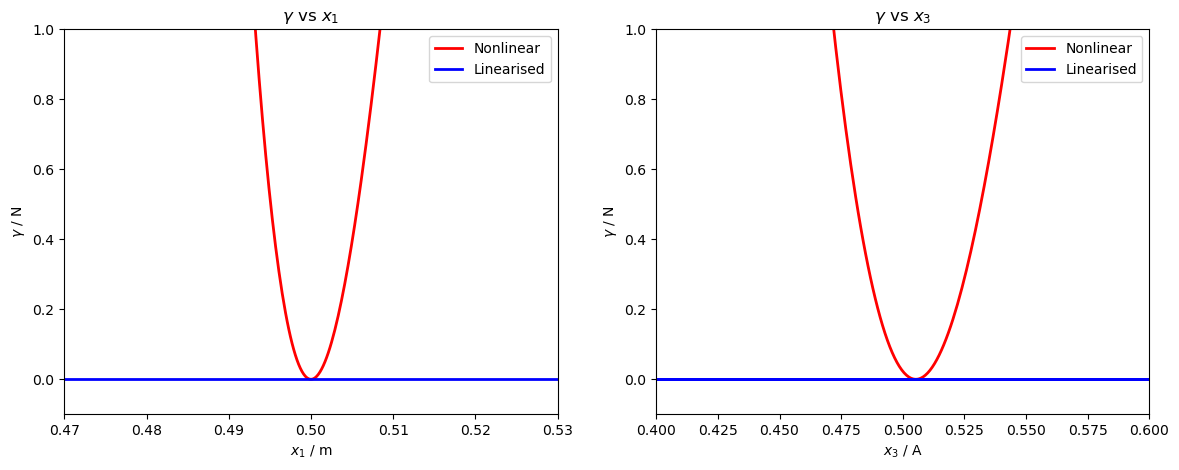

In [ ]:
x1 = np.linspace(0.4, 0.6, 1000)
x3 = np.array((delta - x1) * np.sqrt((k * (x1 - d) - m * g * np.sin(phi)) / c))
gamma_nonlinear = (x3**2 * c / ((delta - x1)) - x_3e**2 * c / ((delta - x_1e)))**2

gamma_linear_x1 = ( (x_3e**2*c) / ( (delta-x_1e)**3 ) ) - k
gamma_linear_x1 = np.full_like(x1,  gamma_linear_x1)

gamma_linear_x3 = ( (x_3e**2*c) / ( (delta-x_1e)**3 ) ) - k
gamma_linear_x3 = np.full_like(x3, gamma_linear_x3)

# Create two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#gamma vs x1
ax1.plot(x1, gamma_nonlinear, 'r-', linewidth=2, label="Nonlinear")
ax1.plot(x1, gamma_linear_x1 - gamma_linear_x3, 'b-', linewidth=2, label="Linearised")
ax1.set_xlim(0.47, 0.53)
ax1.set_ylim(-0.1, 1)
ax1.set_title(r"$\gamma$ vs $x_1$ at equilibrium")
ax1.set_xlabel(r"$x_1$ / m")
ax1.set_ylabel(r"$\gamma$ / N")
ax1.legend()

#gamma vs x3
ax2.plot(x3, gamma_nonlinear, 'r-', linewidth=2, label="Nonlinear")
ax2.plot(x3, gamma_linear_x1 - gamma_linear_x3, 'b-', linewidth=2, label="Linearised")
ax2.set_xlim(0.4, 0.6)
ax2.set_ylim(-0.1, 1)
ax2.set_title(r'$\gamma$ vs $x_3$ at equilibrium')
ax2.set_xlabel(r"$x_3$ / A")
ax2.set_ylabel(r"$\gamma$ / N")
ax2.legend()

plt.show()

Note the RuntimeWarning. This is due to the system having no possible equilibrium point at $x_{1e} < d + mgsin(\phi)$, since physically, the electromagnet cannot exert a repulsive force upon the ball.

C:\Users\Kairl Lau\AppData\Local\Temp\ipykernel_20308\2740594549.py:2: RuntimeWarning: invalid value encountered in sqrt
  x3 = np.array((delta - x1) * np.sqrt((k * (x1 - d) - m * g * np.sin(phi)) / c))


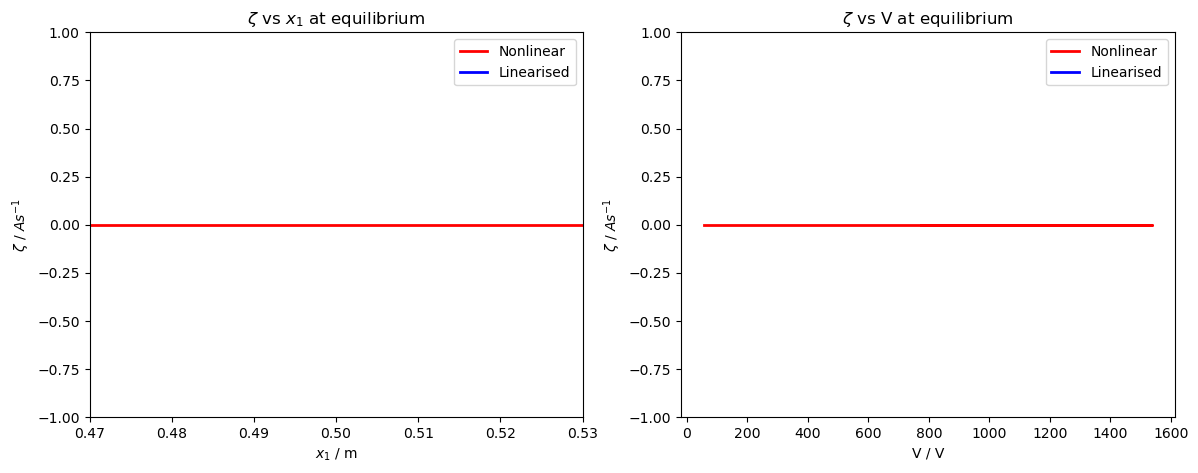

In [79]:
x1 = np.linspace(0.4, 0.6, 1000)
x3 = np.array((delta - x1) * np.sqrt((k * (x1 - d) - m * g * np.sin(phi)) / c))
V = x3 * R
zeta_nonlinear = (V - x3*R)/(L0+L1*np.exp(-alpha*(delta - x1))) - (V_e - x_3e*R)/(L0+L1*np.exp(-alpha*(delta - x_1e)))

zeta_linear_x3 = - (R) / (L0 + L1 * np.exp(-alpha * (delta - x_1e)))
zeta_linear_x3 = np.full_like(x3,  zeta_linear_x3)

zeta_linear_V = - 1 / (L0 + L1 * np.exp(-alpha * (delta - x_1e)))
zeta_linear_V = np.full_like(V, zeta_linear_V)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#gamma vs x3
ax1.plot(x1, zeta_nonlinear, 'r-', linewidth=2, label="Nonlinear")
ax1.plot(x1, zeta_linear_V - zeta_linear_x3, 'b-', linewidth=2, label="Linearised")
ax1.set_xlim(0.47, 0.53)
ax1.set_ylim(-1, 1)
ax1.set_title(r"$\zeta$ vs $x_1$ at equilibrium")
ax1.set_xlabel(r"$x_1$ / m")
ax1.set_ylabel(r"$\zeta$ / $As^{-1}$")
ax1.legend()

#gamma vs V
ax2.plot(V, zeta_nonlinear, 'r-', linewidth=2, label="Nonlinear")
ax2.plot(V, zeta_linear_V - zeta_linear_x3, 'b-', linewidth=2, label="Linearised")
ax2.set_ylim(-1, 1)
ax2.set_title(r"$\zeta$ vs V at equilibrium")
ax2.set_xlabel(r"V / V")
ax2.set_ylabel(r"$\zeta$ / $As^{-1}$")
ax2.legend()

$\zeta$ is Linear because at equilibrium, $\bar{\dot{x_3}}$ is 0 since $\zeta$ = $\bar{\dot{x_3}}$

However, $\gamma$ is very nonlinear, having the linearised version as the tangent to the trough of $\gamma$. Even a 0.01m difference in setpoint makes it so the whole linearised function must be revaluated. The location of the linear tangent at the given setpoint of $x_1 = 0.5m$ is what makes a fixed-gain controller so unstable at other setpoints. Due to this nonlinearity, the proposed controller must implement gain scheduling to remain stable.